# **Library import ও Data load**

In [14]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
import plotly.express as px
import json

# Corrected paths — notebook is inside "code" folder, data is one level up
BASE_DIR = "../../data"
TRAIN_DIR = os.path.join(BASE_DIR, "train_images")

df = pd.read_csv(os.path.join(BASE_DIR, "train.csv"))

with open(os.path.join(BASE_DIR, "label_num_to_disease_map.json")) as f:
    label_map = json.load(f)
label_map = {int(k): v for k, v in label_map.items()}

df["disease_name"] = df["label"].map(label_map)

print("Total images:", len(df))
df.head()

Total images: 21397


,image_id,label,disease_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)


# **Summary Table**

In [15]:
summary = df["disease_name"].value_counts().reset_index()
summary.columns = ["Disease Name", "Number of Images"]
summary["Percentage"] = round((summary["Number of Images"] / len(df)) * 100, 2)

print(summary)

                          Disease Name  Number of Images  Percentage
0         Cassava Mosaic Disease (CMD)             13158       61.49
1                              Healthy              2577       12.04
2           Cassava Green Mottle (CGM)              2386       11.15
3  Cassava Brown Streak Disease (CBSD)              2189       10.23
4       Cassava Bacterial Blight (CBB)              1087        5.08


# **Class Balance**

In [16]:
counts = df["disease_name"].value_counts()

majority_count = counts.max()
minority_count = counts.min()
ratio = majority_count / minority_count

print("Majority class:", counts.idxmax(), "->", majority_count)
print("Minority class:", counts.idxmin(), "->", minority_count)
print("Imbalance Ratio:", round(ratio, 2), ": 1")


fig = px.bar(x=counts.index, y=counts.values, 
             title="Disease Class",
             labels={"x": "Disease Name", "y": "Image Count"})
fig.show()

Majority class: Cassava Mosaic Disease (CMD) -> 13158
Minority class: Cassava Bacterial Blight (CBB) -> 1087
Imbalance Ratio: 12.1 : 1


# **Labelled sample**

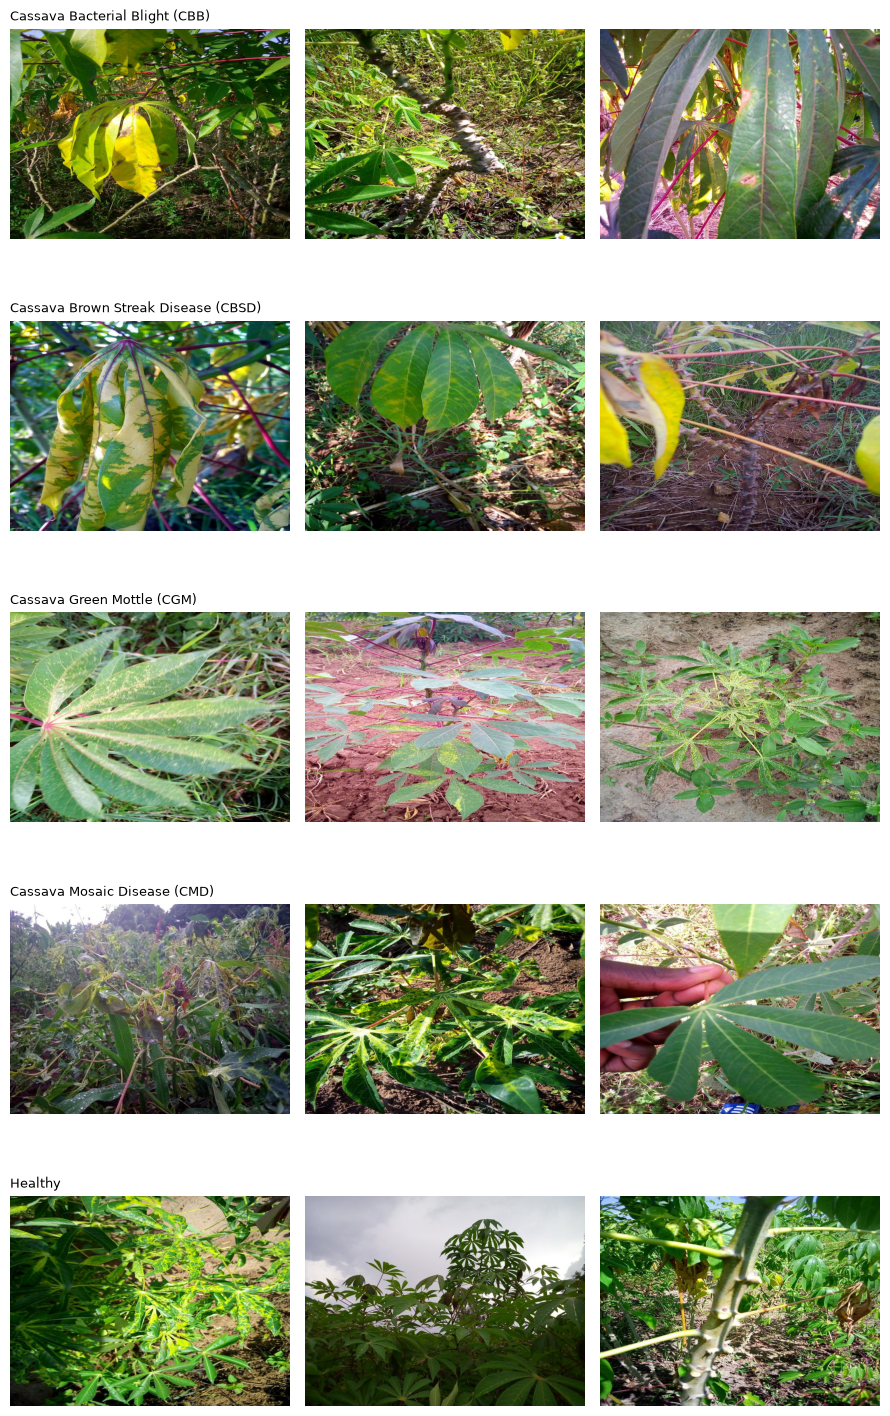

In [17]:
classes = sorted(df["label"].unique())

fig, axes = plt.subplots(len(classes), 3, figsize=(9, 15))

for i, cls in enumerate(classes):
    
    samples = df[df["label"] == cls].sample(3, random_state=1)
    
    for j, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(TRAIN_DIR + "/" + row["image_id"])
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(label_map[cls], fontsize=9, loc="left")

plt.tight_layout()
plt.show()

# **Size/Resolution check**

In [18]:
# Checking only 100 sample images to save time
sample_df = df.sample(100, random_state=1).reset_index(drop=True)

widths = []
heights = []

for img_id in sample_df["image_id"]:
    img = Image.open(TRAIN_DIR + "/" + img_id)
    w, h = img.size
    widths.append(w)
    heights.append(h)

sample_df["width"] = widths
sample_df["height"] = heights

print("Width range:", sample_df["width"].min(), "-", sample_df["width"].max())
print("Height range:", sample_df["height"].min(), "-", sample_df["height"].max())
print("\nUnique resolutions found:")
print(sample_df[["width","height"]].drop_duplicates())

Width range: 800 - 800
Height range: 600 - 600

Unique resolutions found:
   width  height
0    800     600


# **Check Color/Brightness**

In [19]:
# Calculating average brightness for each image
brightness_list = []

for img_id in sample_df["image_id"]:
    img = Image.open(TRAIN_DIR + "/" + img_id)
    img_array = np.array(img)  # convert image to number array
    avg_brightness = img_array.mean()  # average of all pixels
    brightness_list.append(avg_brightness)

sample_df["brightness"] = brightness_list

# Interactive histogram
fig = px.histogram(sample_df, x="brightness", 
                    title="Brightness Distribution of Images",
                    labels={"brightness": "Average Brightness"})
fig.show()

print("Overall average brightness:", round(sample_df["brightness"].mean(), 2))

Overall average brightness: 103.21


# **Check for Blurry/Corrupted Images**

In [20]:
import cv2

# Laplacian variance tells us if image is sharp or blurry
# Lower score = blurry, Higher score = sharp

blur_scores = []

for img_id in sample_df["image_id"]:
    img_path = TRAIN_DIR + "/" + img_id
    gray_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    score = cv2.Laplacian(gray_img, cv2.CV_64F).var()
    blur_scores.append(score)

sample_df["sharpness_score"] = blur_scores

fig = px.histogram(sample_df, x="sharpness_score",
                    title="Sharpness Score Distribution (Lower = Blurry)")
fig.show()

# Show top 3 blurriest images
blurry = sample_df.nsmallest(3, "sharpness_score")
print("Blurriest images found:")
print(blurry[["image_id", "disease_name", "sharpness_score"]])

Blurriest images found:
          image_id                         disease_name  sharpness_score
15  4161798280.jpg                              Healthy        81.564557
24  4080945037.jpg         Cassava Mosaic Disease (CMD)       212.503083
13  4080639262.jpg  Cassava Brown Streak Disease (CBSD)       275.110620


# **Interactive Plots**

In [21]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Showing 4 plots together in a 2x2 grid
fig = make_subplots(rows=2, cols=2,
                     subplot_titles=("Class Distribution", "Resolution", 
                                      "Brightness", "Sharpness"))

# Plot 1: class distribution bar
fig.add_trace(go.Bar(x=counts.index, y=counts.values, showlegend=False), row=1, col=1)

# Plot 2: resolution scatter
fig.add_trace(go.Scatter(x=sample_df["width"], y=sample_df["height"], 
                          mode="markers", showlegend=False), row=1, col=2)

# Plot 3: brightness histogram
fig.add_trace(go.Histogram(x=sample_df["brightness"], showlegend=False), row=2, col=1)

# Plot 4: sharpness histogram
fig.add_trace(go.Histogram(x=sample_df["sharpness_score"], showlegend=False), row=2, col=2)

fig.update_layout(height=700, title_text="EDA Summary Dashboard")
fig.show()

In [23]:
counts = df["disease_name"].value_counts()

fig = px.pie(values=counts.values, names=counts.index,
             title="Percentage of Each Disease Class")
fig.show()